# Olist: Delivery Time Prediction Model

## 1. Data preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib
from sklearn.ensemble import HistGradientBoostingRegressor

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

clean = pd.read_parquet("../data/clean/clean.parquet")
print(clean.shape)

(96164, 38)


## 2. Time-based split

In [2]:
clean = clean.sort_values('order_purchase_timestamp').reset_index(drop=True)

split_point = int(len(clean)*0.8)
train = clean.iloc[:split_point]
test = clean.iloc[split_point:]

val_point = int(len(train)*0.85)
train_core = train.iloc[:val_point]
val = train.iloc[val_point:]

print("Train size: ", len(train))
print("  Train core: ", len(train_core))
print("  Val size:   ", len(val))
print("Test size: ", len(test))
print("Train core until: ", train_core['order_purchase_timestamp'].max())
print("Val from: ", val['order_purchase_timestamp'].min())
print("Val until: ", val['order_purchase_timestamp'].max())
print("Test from: ", test['order_purchase_timestamp'].min())
print("Test until: ", test['order_purchase_timestamp'].max())

Train size:  76931
  Train core:  65391
  Val size:    11540
Test size:  19233
Train core until:  2018-04-06 16:41:40
Val from:  2018-04-06 16:46:08
Val until:  2018-05-27 11:44:23
Test from:  2018-05-27 11:55:26
Test until:  2018-08-29 15:00:37


Time-based split: train 76,931 (until 2018-05-27), test 19,233 (Jun–Aug 2018). Validation: last 15% of train (Apr–May 2018). All decisions (ablation, model choice, tuning) are made on validation. Test is used once, at the end. Test covers Jun–Aug 2018, the fastest period, no winter months.

In [3]:
cat_cols = ['customer_state', 'seller_state', 'product_category_name', 'customer_city_grouped']
num_fill = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
            'volume_cm3', 'distance_km']

for col in cat_cols:
    cats = train_core[col].astype('category').cat.categories
    clean[col + '_code'] = pd.Categorical(clean[col], categories=cats).codes

medians = train_core[num_fill].median()
clean[num_fill] = clean[num_fill].fillna(medians)

train = clean.iloc[:split_point]
test = clean.iloc[split_point:]
train_core = train.iloc[:val_point]
val = train.iloc[val_point:]

print("NaN left:", clean[num_fill].isnull().sum().sum())
print("Unknown categories in test:", (test[[c + '_code' for c in cat_cols]] == -1).sum().sum())

NaN left: 0
Unknown categories in test: 11


Preprocessing after the split: category codes and medians are fitted on train_core only, unknown categories in test get code -1.

## 3. Baselines on validation

In [4]:
naive_pred_val = train_core['delivery_days'].mean()
mae_naive_val = (val['delivery_days'] - naive_pred_val).abs().mean()
mae_olist_val = val['estimation_error'].abs().mean()

print("Naive MAE (val): ", mae_naive_val)
print("Olist MAE (val): ", mae_olist_val)

Naive MAE (val):  6.5396499359260245
Olist MAE (val):  12.434662045060659


Baselines on validation: naive (train_core mean) MAE 6.54, Olist estimate 12.43. Target for the model: below 6.54.

## 4. RandomForest

In [5]:
FEATURES = ['purchase_month', 'purchase_day_of_week', 'purchase_year', 'total_price',
            'total_freight', 'quantity_items', 'same_state', 'product_weight_g', 'volume_cm3',
            'customer_state_code', 'seller_state_code', 'product_category_name_code', 'customer_city_grouped_code']


print("Missing: ", [c for c in FEATURES if c not in clean.columns])

Missing:  []


In [6]:
TARGET = 'delivery_days'

X_train = train_core[FEATURES]
Y_train = train_core[TARGET]
X_val   = val[FEATURES]
Y_val   = val[TARGET]

print(X_train.shape, X_val.shape)

(65391, 13) (11540, 13)


In [7]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, Y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [8]:
pred = model_rf.predict(X_val)

mae_model_rf = mean_absolute_error(Y_val, pred)
r2_model_rf = r2_score(Y_val, pred)

print("R2 score Random Forest: ", r2_model_rf)
print("MAE score Random Forest: ", mae_model_rf)
print("MAE naive (val): ", mae_naive_val)
print("MAE Olist (val): ", mae_olist_val)

R2 score Random Forest:  0.23303833095579973
MAE score Random Forest:  5.054595089012182
MAE naive (val):  6.5396499359260245
MAE Olist (val):  12.434662045060659


## 5. Error analysis

In [9]:
errors_rf = (Y_val - pred).abs()
print(errors_rf.describe().round(2))
print("Errors > 15 days:", (errors_rf > 15).sum())

count    11540.00
mean         5.05
std          4.44
min          0.00
25%          1.96
50%          4.01
75%          6.85
max         41.61
Name: delivery_days, dtype: float64
Errors > 15 days: 381


Median error 4.0 days, 75% of orders within 6.9. 381 orders (3.3%) miss by more than 15 days, the model cannot predict rare long delays. R² on validation is +0.23 vs −0.19 on an earlier test window, so R² is unstable across periods and MAE stays the primary metric.

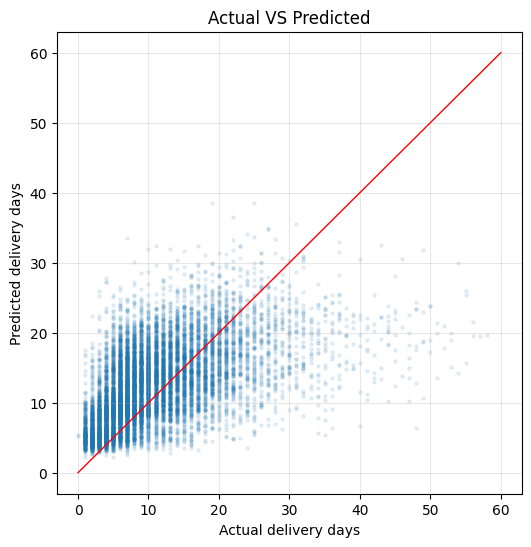

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(Y_val, pred, alpha=0.1, s = 5)
plt.plot([0,60],[0,60], color='Red', linewidth = 1)
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual VS Predicted")
plt.show()

Typical deliveries sit on the diagonal. Delays of 30+ days are predicted as 10–20 and model can't see them coming.

## 6. Feature importances

In [11]:
importances = pd.Series(model_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.round(3))

same_state                    0.158
total_freight                 0.127
total_price                   0.113
volume_cm3                    0.108
product_weight_g              0.100
customer_state_code           0.085
product_category_name_code    0.069
purchase_month                0.069
purchase_day_of_week          0.062
customer_city_grouped_code    0.046
purchase_year                 0.031
seller_state_code             0.024
quantity_items                0.009
dtype: float64


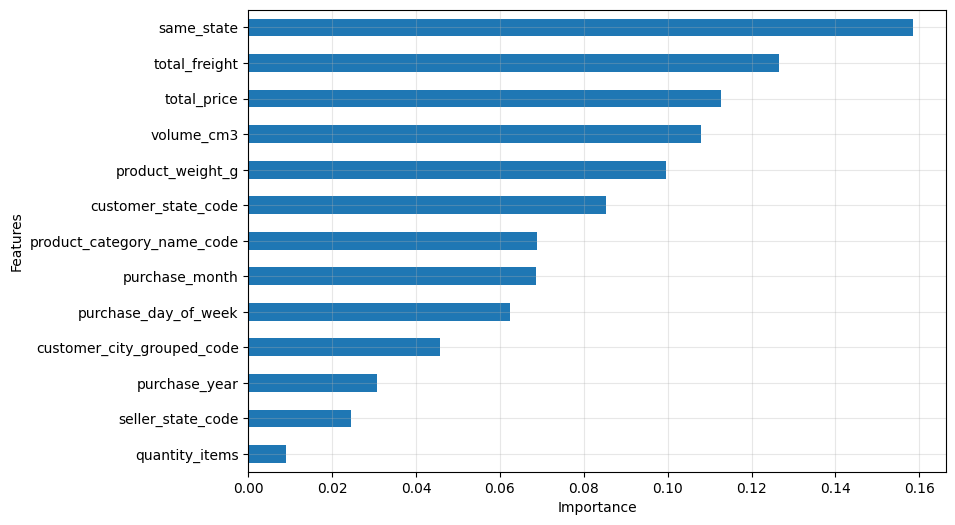

In [12]:
importances.sort_values().plot.barh(figsize=(9, 6))
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

## 7. Feature ablation

Checking whether the four weakest features (by importance) actually contribute to MAE or just add noise. Threshold: 0.02 days.

In [13]:
DROP = ['customer_city_grouped_code', 'seller_state_code', 'purchase_year', 'quantity_items']

FEATURES_SLIM = [f for f in FEATURES if f not in DROP]

model_rf_slim = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_slim.fit(train_core[FEATURES_SLIM], Y_train)
pred_rf_slim = model_rf_slim.predict(val[FEATURES_SLIM])

print("Features: ", len(FEATURES_SLIM))
print("MAE slim: ", round(mean_absolute_error(Y_val, pred_rf_slim), 3))
print("MAE full: ", round(mae_model_rf, 3))

Features:  9
MAE slim:  4.953
MAE full:  5.055


Dropped the four weakest features (customer_city, seller_state, purchase_year, quantity_items). MAE improved from 5.05 to 4.95 on validation. Weak features were adding noise.

## 8. HistGradientBoosting

In [14]:
model_hgb = HistGradientBoostingRegressor(random_state=42)
model_hgb.fit(train_core[FEATURES_SLIM], Y_train)
pred_hgb = model_hgb.predict(val[FEATURES_SLIM])

print("MAE HGB slim: ", mean_absolute_error(Y_val, pred_hgb))
print("MAE RF slim: ", mean_absolute_error(Y_val, pred_rf_slim))

MAE HGB slim:  4.714827463467713
MAE RF slim:  4.952607588911185


In [15]:
print("R2: ", r2_score(Y_val, pred_hgb))

errors_hgb = round((Y_val - pred_hgb).abs(), 3)
print("Errors > 15: ", (errors_hgb > 15).sum())

R2:  0.3126240404278474
Errors > 15:  372


HistGradientBoosting on the same 9 features: MAE 4.71 vs 4.95 RF on validation. The largest single gain so far.

## 9. Distance feature

In [16]:
FEATURES_GEO = FEATURES_SLIM + ['distance_km']

In [17]:
model_hgb_geo = HistGradientBoostingRegressor(random_state=42)
model_hgb_geo.fit(train_core[FEATURES_GEO], Y_train)
pred_hgb_geo = model_hgb_geo.predict(val[FEATURES_GEO])

print("MAE HGB slim + geo: ", mean_absolute_error(Y_val, pred_hgb_geo))
print("MAE HGB slim: ", mean_absolute_error(Y_val, pred_hgb))

MAE HGB slim + geo:  4.595732035256666
MAE HGB slim:  4.714827463467713


distance_km added: MAE 4.71 to 4.60 on validation. Corrected haversine carries geographic signal that state and freight alone do not.

## 10. Hyperparameter tuning

In [18]:
param_grid ={
    'max_iter': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [None, 6]
}

tscv = TimeSeriesSplit(n_splits=3, test_size=5000)

grid = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid.fit(train[FEATURES_GEO], train[TARGET])

print("Best params: ", grid.best_params_)
print("Best CV MAE: ", round(-grid.best_score_, 3))

Best params:  {'learning_rate': 0.05, 'max_depth': 6, 'max_iter': 300}
Best CV MAE:  4.713


In [19]:
model_tuned_val = HistGradientBoostingRegressor(**grid.best_params_, random_state=42)
model_tuned_val.fit(train_core[FEATURES_GEO], Y_train)
pred_tuned_val = model_tuned_val.predict(val[FEATURES_GEO])

print("MAE tuned (val): ", round(mean_absolute_error(Y_val, pred_tuned_val), 3))
print("MAE default (val):", round(mean_absolute_error(Y_val, pred_hgb_geo), 3))

MAE tuned (val):  4.575
MAE default (val): 4.596


In [20]:
final_model = HistGradientBoostingRegressor(**grid.best_params_, random_state=42)
final_model.fit(train[FEATURES_GEO], train[TARGET])
pred_final = final_model.predict(test[FEATURES_GEO])

print("MAE test (final):", round(mean_absolute_error(test[TARGET], pred_final), 3))
print("R2 test (final):", round(r2_score(test[TARGET], pred_final), 3))

MAE test (final): 4.047
R2 test (final): 0.121


In [21]:
naive_pred = train['delivery_days'].mean()
mae_naive = (test['delivery_days'] - naive_pred).abs().mean()
mae_olist = test['estimation_error'].abs().mean()

print("Naive MAE (test):", round(mae_naive, 2))
print("Olist MAE (test):", round(mae_olist, 2))

Naive MAE (test): 6.19
Olist MAE (test): 13.17


GridSearch with TimeSeriesSplit on recent windows: best params lr 0.05, depth 6, 300 iterations, CV MAE 4.71. On validation tuned beats default 4.575 vs 4.596, so the tuned configuration is refit on full train as the final model.

In [22]:
preds = {}

m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
m.fit(train[FEATURES_SLIM], train[TARGET])
preds['RF, 9 features'] = m.predict(test[FEATURES_SLIM])

m = HistGradientBoostingRegressor(random_state=42)
m.fit(train[FEATURES_SLIM], train[TARGET])
preds['HGB'] = m.predict(test[FEATURES_SLIM])

m = HistGradientBoostingRegressor(random_state=42)
m.fit(train[FEATURES_GEO], train[TARGET])
preds['HGB + distance'] = m.predict(test[FEATURES_GEO])

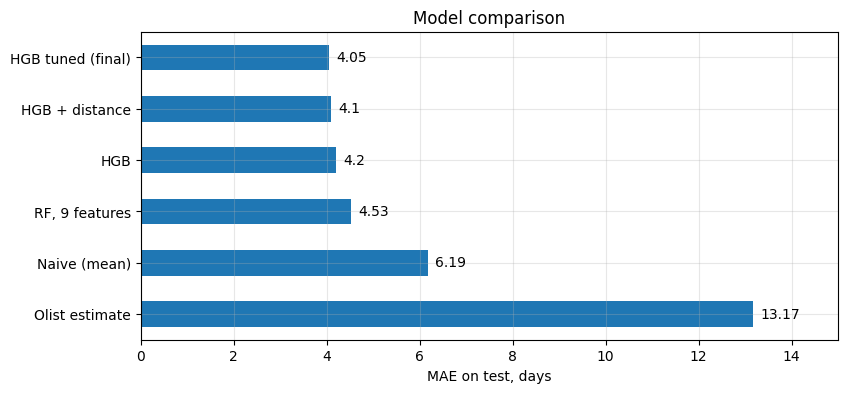

In [23]:
results = pd.Series({
    'Olist estimate': round(mae_olist, 2),
    'Naive (mean)': round(mae_naive, 2),
    **{name: round(mean_absolute_error(test[TARGET], p), 2) for name, p in preds.items()},
    'HGB tuned (final)': round(mean_absolute_error(test[TARGET], pred_final), 2),
}).sort_values(ascending=False)

ax = results.plot.barh(figsize=(9, 4))
for i, v in enumerate(results):
    ax.text(v + 0.15, i, str(v), va='center')

plt.xlim(0, 15)
plt.xlabel("MAE on test, days")
plt.title("Model comparison")
plt.savefig('../images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

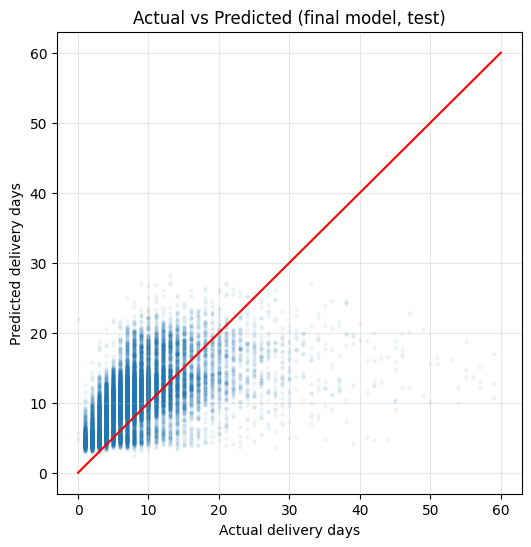

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(test[TARGET], pred_final, alpha=0.06, s=5)
plt.plot([0, 60], [0, 60], color='red')
plt.xlabel("Actual delivery days")
plt.ylabel("Predicted delivery days")
plt.title("Actual vs Predicted (final model, test)")
plt.savefig('../images/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
joblib.dump(final_model, "../models/hgb_final.joblib")
joblib.dump(FEATURES_GEO, "../models/features.joblib")

['../models/features.joblib']

## Summary

Final model: HistGradientBoosting (lr 0.05, depth 6, 300 iterations) with 10 features. MAE 4.05 on test vs 6.19 naive baseline and 13.17 Olist estimate, a 35% improvement over naive. All decisions were made on a validation window inside train, the test set was used once for final evaluation.

R2 is positive but low. Rare long delays are not predictable from order-time features.